# Timing execution around liquidity

**Use case: [Execute smarter](https://aperiodic.io/use-cases/execute-smarter)**

Execution cost is not constant through the day. Spreads widen, depth thins, and
order flow turns adverse together around stressed periods. For a
moderate-frequency order, *when* you execute can matter more than shaving
microseconds off the route. This notebook measures when liquidity is deep,
spreads are narrow, and flow is least toxic, then ranks the hours by modelled
execution cost and cross-checks that ranking against measured slippage.

We study **Binance BTC perpetuals** (`perpetual-BTC-USDT:USDT`) at **5-minute**
resolution over **May 2025**, the window served by the shared `DEMO-KEY` preview
slice. The multi-level **L2** datasets are tier 3; they are included in the
preview slice, so this notebook runs in preview mode, but full L2 **history**
requires a Prime subscription.

> **One month is an illustration, not evidence.** All cost differences and
> seasonality below come from a single month of 5-minute data. May 2025
> seasonality will not necessarily persist; treat every figure as illustrative.
> Exchange **fees** are omitted throughout: a constant per-clip taker fee shifts
> every schedule equally and cancels in the comparison, so it does not affect
> *which* hours are cheaper (it is central to `backtest-slippage.py`, though).

**Background reading**
- Aperiodic L1 metrics: https://aperiodic.io/metrics/l1
- Aperiodic L2 metrics: https://aperiodic.io/metrics/l2

## 1. Execution cost changes through time

Spread, depth, volatility, and informed (toxic) flow are not independent. When
volatility spikes, market makers widen quotes and pull depth, and the flow that
trades against you is more likely to be informed. The result is that the *same*
order costs very different amounts depending on the hour.

This is an exercise in **historical scheduling** for moderate-frequency
execution — choosing better windows from recurring conditions — not low-latency
routing. Historical analysis still needs Live data to operate going forward.

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configuration

Uppercase constants hold the public parameters. Timestamps are **exchange-reported
(UTC)** throughout; every hour-of-day / day-of-week aggregation below is derived
from that single, documented timezone. The API key resolves **inline value →
`APERIODIC_API_KEY` → `DEMO-KEY`**.

In [2]:
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 5, 1)
END_DATE = date(2025, 5, 31)
TIMESTAMP = "exchange"  # exchange-reported (UTC) time
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

# Fixed order size (USD notional) priced by the schedules, and how many best/worst
# hours each schedule selects.
ORDER_NOTIONAL = 50_000
BEST_K_HOURS = 4
# Multi-depth L2 aggregation levels and the representative level for the heatmap.
L2_LEVELS = [5, 10, 20, 25]
DEPTH_LEVEL = 20
# Minimum bars per (weekday, hour) cell before a seasonality cell is trusted.
MIN_CELL_BARS = 12

API_KEY = "..."  # Set your key here, or via the APERIODIC_API_KEY env var
if API_KEY == "...":
    API_KEY = os.environ.get("APERIODIC_API_KEY", "DEMO-KEY")

# Only the shared "DEMO-KEY" runs against the preview endpoint. Provide your own
# key (above or via APERIODIC_API_KEY) to use the standard endpoint.
USE_PREVIEW = API_KEY == "DEMO-KEY"

print(f"Exchange / symbol : {EXCHANGE} / {SYMBOL}")
print(f"Interval / window : {INTERVAL} | {START_DATE} → {END_DATE}")
print(f"Order notional    : ${ORDER_NOTIONAL:,} | best/worst hours: {BEST_K_HOURS}")
print(f"Mode              : {'preview (DEMO-KEY)' if USE_PREVIEW else 'standard endpoint'}")

Exchange / symbol : binance-futures / perpetual-BTC-USDT:USDT
Interval / window : 5m | 2025-05-01 → 2025-05-31
Order notional    : $50,000 | best/worst hours: 4
Mode              : standard endpoint


## Helper functions

`clip_window` and `format_time_axis` match the introductory notebooks;
`expected_cost_bps` is the same half-spread-plus-impact model built in
`backtest-slippage.py`; `pct_rank`, `season_pivot`, and `quintile_labels` support
the score, the seasonality heatmaps, and robust quintile binning; and
`audit_columns` prints the fetched schema and fails loudly if a field is absent.

In [3]:
def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def audit_columns(frames: dict[str, tuple[pd.DataFrame, list[str]]]) -> None:
    lines, problems = [], []
    for name, (frame, required) in frames.items():
        cols = sorted(map(str, frame.columns))
        missing = [c for c in required if c not in frame.columns]
        lines.append(f"- {name:<14} {len(frame):>5} rows | columns={cols}")
        if missing:
            problems.append(f"{name} missing {missing}")
    report = "Fetched schema:\n" + "\n".join(lines)
    print(report)
    if problems:
        raise KeyError("; ".join(problems) + "\n" + report)


def expected_cost_bps(half_spread_bps, impact_coef_bps_per_usd, order_notional: float) -> np.ndarray:
    """One-way expected microstructure cost (bps) = half_spread_bps +
    impact_coef_bps_per_usd * order_notional. Same unit convention as
    backtest-slippage.py (fees excluded); inputs used as-is."""
    half_spread_bps = np.asarray(half_spread_bps, dtype=np.float64)
    impact_coef_bps_per_usd = np.asarray(impact_coef_bps_per_usd, dtype=np.float64)
    return half_spread_bps + impact_coef_bps_per_usd * float(order_notional)


def pct_rank(series: pd.Series) -> pd.Series:
    """Cross-sectional percentile rank in [0, 1] over the whole in-window sample."""
    return series.rank(pct=True)


def season_pivot(frame: pd.DataFrame, value: str, aggfunc: str = "median") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Weekday x hour-of-day pivot of `value`, plus a matching bar-count pivot."""
    tmp = frame.assign(weekday=frame["time"].dt.day_name().str[:3], hour=frame["time"].dt.hour)
    order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    grid = tmp.pivot_table(index="weekday", columns="hour", values=value, aggfunc=aggfunc).reindex(order)
    counts = tmp.pivot_table(index="weekday", columns="hour", values=value, aggfunc="count").reindex(order)
    return grid, counts


def quintile_labels(series: pd.Series, q: int = 5) -> pd.Series:
    """Q1..Qk labels from quantile bins, robust to dropped bins (never raises)."""
    codes = pd.qcut(series, q, labels=False, duplicates="drop")
    return codes.map(lambda c: f"Q{int(c) + 1}" if pd.notna(c) else np.nan)


def rank_corr(a: pd.Series, b: pd.Series) -> float:
    """Spearman rank correlation as Pearson-on-ranks (no SciPy dependency)."""
    idx = a.index.intersection(b.index)
    if len(idx) < 2:
        return float("nan")
    return float(a.loc[idx].rank().corr(b.loc[idx].rank()))

## 3. Fetch and align market data

Seven requests share the common arguments (`api_key`, `preview`, `timestamp`,
`interval`, `exchange`, `symbol`, `start_date`, `end_date`, `output="pandas"`,
`show_progress=False`): price, L1 prices, multi-level L2 liquidity, multi-level
L2 imbalance, order flow, market impact, and measured **slippage** (used to
validate the model's hourly ranking against catalogue ground truth). We clip each
to the window and join on `time`.

In [4]:
COMMON = dict(
    api_key=API_KEY,
    preview=USE_PREVIEW,
    timestamp=TIMESTAMP,
    interval=INTERVAL,
    exchange=EXCHANGE,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    output="pandas",
    show_progress=False,
)

ohlcv = clip_window(get_ohlcv(**COMMON))
l1_price = clip_window(get_metrics(metric="l1_price", **COMMON))
l2_liquidity = clip_window(get_metrics(metric="l2_liquidity", **COMMON))
l2_imbalance = clip_window(get_metrics(metric="l2_imbalance", **COMMON))
flow = clip_window(get_metrics(metric="flow", **COMMON))
impact = clip_window(get_metrics(metric="impact", **COMMON))
slippage = clip_window(get_metrics(metric="slippage", **COMMON))

bid_cols = [f"bid_agg_{lvl}" for lvl in L2_LEVELS]
ask_cols = [f"ask_agg_{lvl}" for lvl in L2_LEVELS]
imb_cols = [f"imbalance_{lvl}" for lvl in L2_LEVELS]
audit_columns(
    {
        "ohlcv": (ohlcv, ["time", "close", "volume"]),
        "l1_price": (l1_price, ["time", "bid_price", "ask_price", "midprice"]),
        "l2_liquidity": (l2_liquidity, ["time", *bid_cols, *ask_cols]),
        "l2_imbalance": (l2_imbalance, ["time", *imb_cols]),
        "flow": (flow, ["time", "flow_toxicity_score"]),
        "impact": (impact, ["time", "impact_per_notional"]),
        "slippage": (slippage, ["time", "slippage_bps_mean"]),
    }
)

Fetched schema:
- ohlcv           8928 rows | columns=['close', 'high', 'low', 'open', 'time', 'volume', 'volume_notional']
- l1_price        8928 rows | columns=['ask_amount', 'ask_price', 'ask_price_twap', 'ask_price_vwap', 'avg_update_interval', 'bid_amount', 'bid_price', 'bid_price_twap', 'bid_price_vwap', 'midprice', 'quote_update_frequency', 'time', 'weighted_midprice']
- l2_liquidity    8928 rows | columns=['ask_agg_10', 'ask_agg_10_avg', 'ask_agg_20', 'ask_agg_20_avg', 'ask_agg_25', 'ask_agg_25_avg', 'ask_agg_5', 'ask_agg_5_avg', 'bid_agg_10', 'bid_agg_10_avg', 'bid_agg_20', 'bid_agg_20_avg', 'bid_agg_25', 'bid_agg_25_avg', 'bid_agg_5', 'bid_agg_5_avg', 'time']
- l2_imbalance    8928 rows | columns=['bid_ask_ratio_10', 'bid_ask_ratio_10_avg', 'bid_ask_ratio_20', 'bid_ask_ratio_20_avg', 'bid_ask_ratio_25', 'bid_ask_ratio_25_avg', 'bid_ask_ratio_5', 'bid_ask_ratio_5_avg', 'imbalance_10', 'imbalance_10_avg', 'imbalance_20', 'imbalance_20_avg', 'imbalance_25', 'imbalance_25_avg', '

In [5]:
df = (
    ohlcv[["time", "close", "volume"]]
    .merge(l1_price[["time", "bid_price", "ask_price", "midprice"]], on="time", how="inner")
    .merge(l2_liquidity[["time", *bid_cols, *ask_cols]], on="time", how="inner")
    .merge(l2_imbalance[["time", *imb_cols]], on="time", how="inner")
    .merge(flow[["time", "flow_toxicity_score"]], on="time", how="inner")
    .merge(impact[["time", "impact_per_notional"]], on="time", how="inner")
    .merge(slippage[["time", "slippage_bps_mean"]], on="time", how="inner")
    .sort_values("time")
    .reset_index(drop=True)
)

# Spread from L1. Depth per level = bid + ask aggregate, in BASE units (BTC) per the
# catalogue (ask_agg_N = "total ask quantity across the top N levels"); we use the
# end-of-bar snapshot (non-`_avg`) as the book state an order would meet on arrival.
df["spread_bps"] = (df["ask_price"] - df["bid_price"]) / df["midprice"] * 1e4
df["half_spread_bps"] = 0.5 * df["spread_bps"]
for lvl in L2_LEVELS:
    df[f"depth_{lvl}"] = df[f"bid_agg_{lvl}"] + df[f"ask_agg_{lvl}"]  # BTC
df[f"dollar_depth_{DEPTH_LEVEL}"] = df[f"depth_{DEPTH_LEVEL}"] * df["close"]  # USD

# flow_toxicity_score is SIGNED (catalogue: "past-normalized SIGNED notional flow x
# normalized vol"); its magnitude is adverse-selection intensity, its sign is flow
# direction. We use |toxicity| everywhere an execution-quality intensity is meant.
df["abs_toxicity"] = df["flow_toxicity_score"].abs()

# Impact coefficient in bps per USD. Catalogue: impact_per_notional = |interval
# return| / |signed notional flow| = a price FRACTION per USD; x1e4 -> bps/USD.
# Non-negative by construction; guard the rare zero-flow inf.
df["impact_coef_bps_per_usd"] = df["impact_per_notional"].replace([np.inf, -np.inf], np.nan) * 1e4
df["expected_cost_bps"] = expected_cost_bps(df["half_spread_bps"], df["impact_coef_bps_per_usd"], ORDER_NOTIONAL)

df["ret"] = df["close"].pct_change()
df["realized_vol_1h_bps"] = df["ret"].rolling(12).std() * np.sqrt(12) * 1e4
df["fwd_abs_move_bps"] = df["close"].pct_change().shift(-1).abs() * 1e4  # lagged features only
df["hour"] = df["time"].dt.hour

# At $50k the cost is almost entirely the impact term (half-spread is ~0.005 bps on
# BTC), so the schedule numbers depend chiefly on impact_per_notional's ×1e4 unit —
# verified against the catalogue definition above.
median_dollar_depth = df[f"dollar_depth_{DEPTH_LEVEL}"].median()
coverage = pd.Series(
    {
        "Rows (5m bars)": len(df),
        "Median spread (bps)": df["spread_bps"].median(),
        f"Median depth L{DEPTH_LEVEL} (BTC)": df[f"depth_{DEPTH_LEVEL}"].median(),
        f"Median dollar depth L{DEPTH_LEVEL} ($)": median_dollar_depth,
        f"ORDER_NOTIONAL as % of L{DEPTH_LEVEL} depth": 100 * ORDER_NOTIONAL / median_dollar_depth,
        "Median |toxicity|": df["abs_toxicity"].median(),
        f"Median expected cost @ ${ORDER_NOTIONAL:,} (bps)": df["expected_cost_bps"].median(),
        "Mean expected cost (bps, heavy-tailed)": df["expected_cost_bps"].mean(),
    }
)
coverage

Rows (5m bars)                               8,928.0000
Median spread (bps)                              0.0096
Median depth L20 (BTC)                          22.3670
Median dollar depth L20 ($)              2,301,821.3415
ORDER_NOTIONAL as % of L20 depth                 2.1722
Median |toxicity|                                0.0890
Median expected cost @ $50,000 (bps)             0.0444
Mean expected cost (bps, heavy-tailed)           0.2141
dtype: float64

## 4. Chart 1 — Spread seasonality

Median spread as an hour-of-day (columns) by day-of-week (rows) heatmap. Cells
with fewer than `MIN_CELL_BARS` observations are masked so the chart does not
imply precision the one-month sample cannot support.

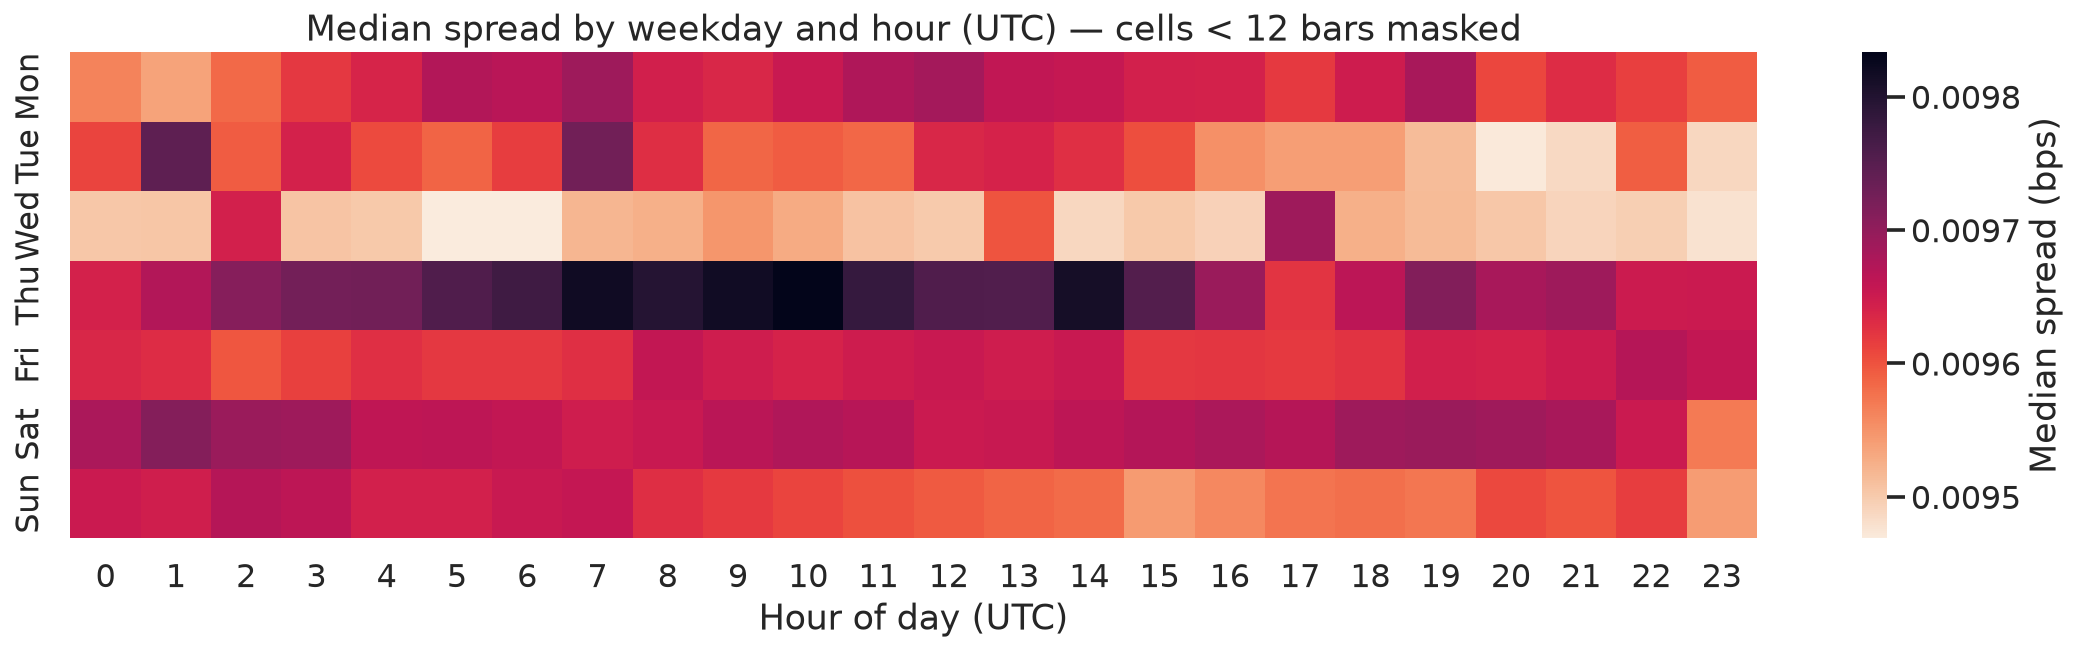

In [6]:
spread_grid, spread_counts = season_pivot(df, "spread_bps", "median")
spread_masked = spread_grid.mask(spread_counts < MIN_CELL_BARS)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(spread_masked, cmap="rocket_r", ax=ax, cbar_kws={"label": "Median spread (bps)"})
ax.set_title(f"Median spread by weekday and hour (UTC) — cells < {MIN_CELL_BARS} bars masked")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("")
plt.tight_layout()

## 5. Chart 2 — Multi-level depth seasonality

The order book is more than the top level. The left panel is an hour/day heatmap
of total depth (BTC) at level `DEPTH_LEVEL`; the right panel compares the average
depth profile by hour across the 5/10/20/25 aggregation levels. The coverage
table above expresses `ORDER_NOTIONAL` as a percentage of level-`DEPTH_LEVEL`
dollar depth so you can judge whether impact should matter at your size.

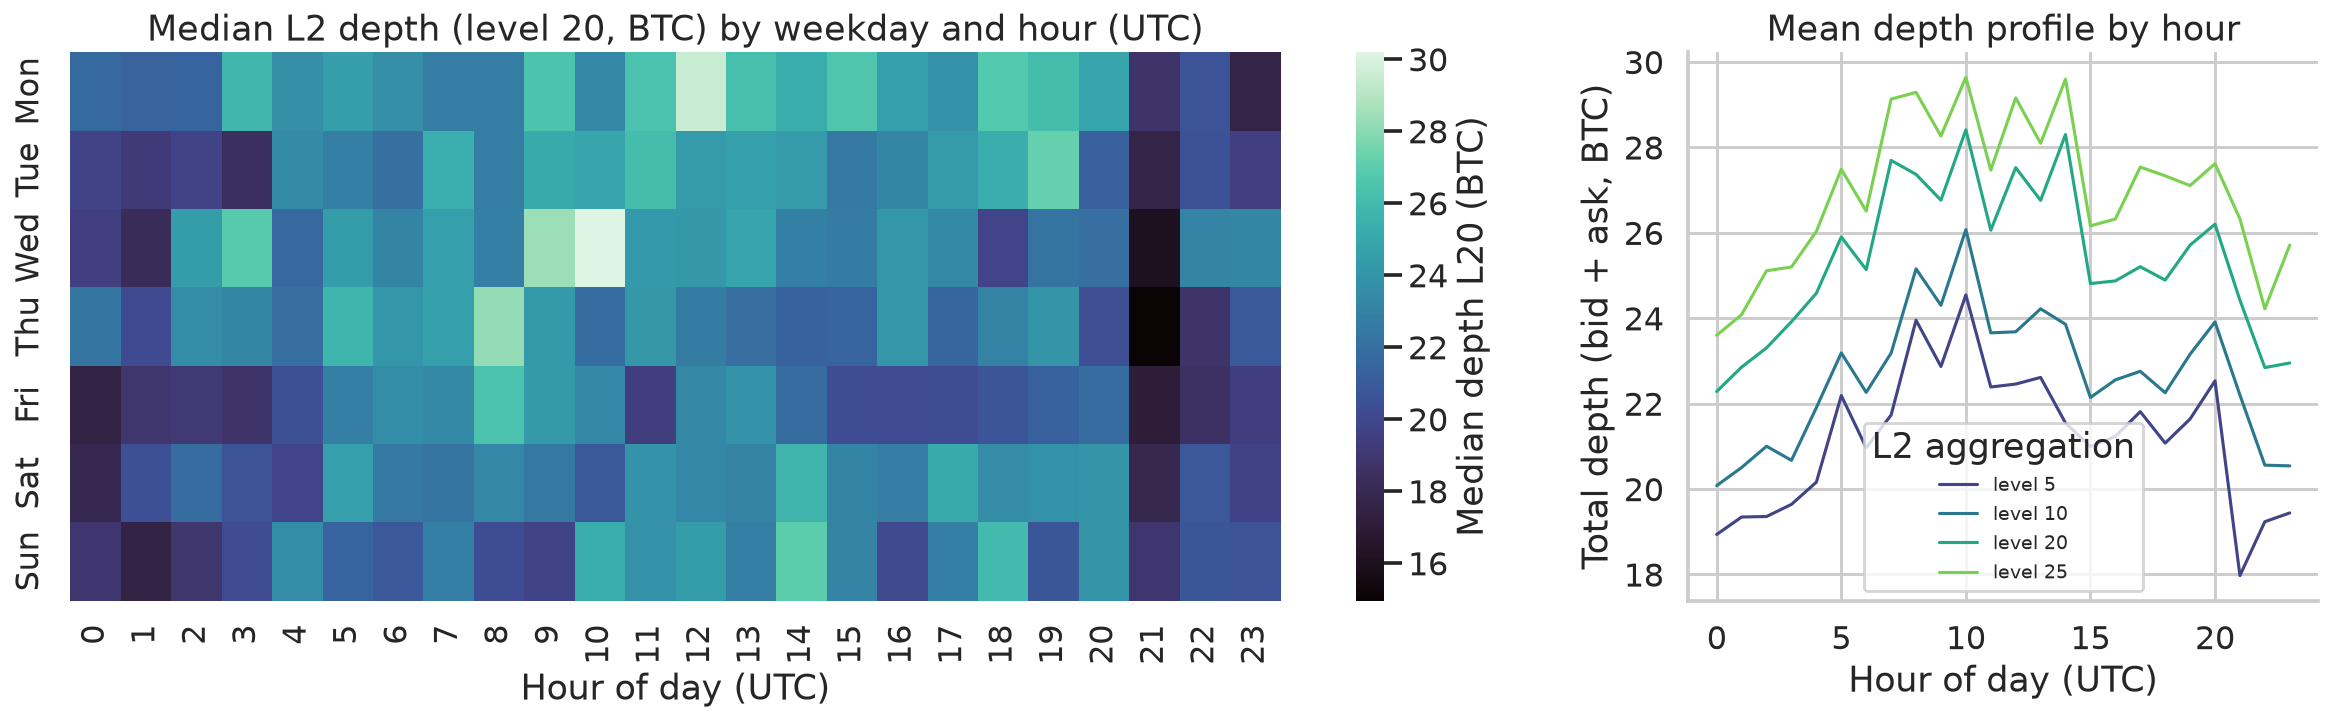

In [7]:
depth_grid, depth_counts = season_pivot(df, f"depth_{DEPTH_LEVEL}", "median")
depth_masked = depth_grid.mask(depth_counts < MIN_CELL_BARS)

fig, (ax_h, ax_p) = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [2.4, 1]})
sns.heatmap(depth_masked, cmap="mako", ax=ax_h, cbar_kws={"label": f"Median depth L{DEPTH_LEVEL} (BTC)"})
ax_h.set_title(f"Median L2 depth (level {DEPTH_LEVEL}, BTC) by weekday and hour (UTC)")
ax_h.set_xlabel("Hour of day (UTC)")
ax_h.set_ylabel("")

hourly_depth = df.groupby("hour")[[f"depth_{lvl}" for lvl in L2_LEVELS]].mean()
palette = sns.color_palette("viridis", len(L2_LEVELS))
for color, lvl in zip(palette, L2_LEVELS):
    ax_p.plot(hourly_depth.index, hourly_depth[f"depth_{lvl}"], color=color, linewidth=1.6, label=f"level {lvl}")
ax_p.set_title("Mean depth profile by hour")
ax_p.set_xlabel("Hour of day (UTC)")
ax_p.set_ylabel("Total depth (bid + ask, BTC)")
ax_p.legend(frameon=True, fontsize=10, title="L2 aggregation")
plt.tight_layout()

## 6. Chart 3 — Volatility and adverse flow

Execution risk is not only about nominal depth. The left panel overlays rolling
realised volatility with the average spread by hour. The right panel relates two
**lagged** features — **|flow toxicity|** and the absolute L2 imbalance known
*before* the move — to the **next-bar** absolute move: bucketed into quintiles,
average subsequent moves rise with both. These are intensity diagnostics (the
signed toxicity is folded to its magnitude), not causal claims, and use only
lagged inputs.

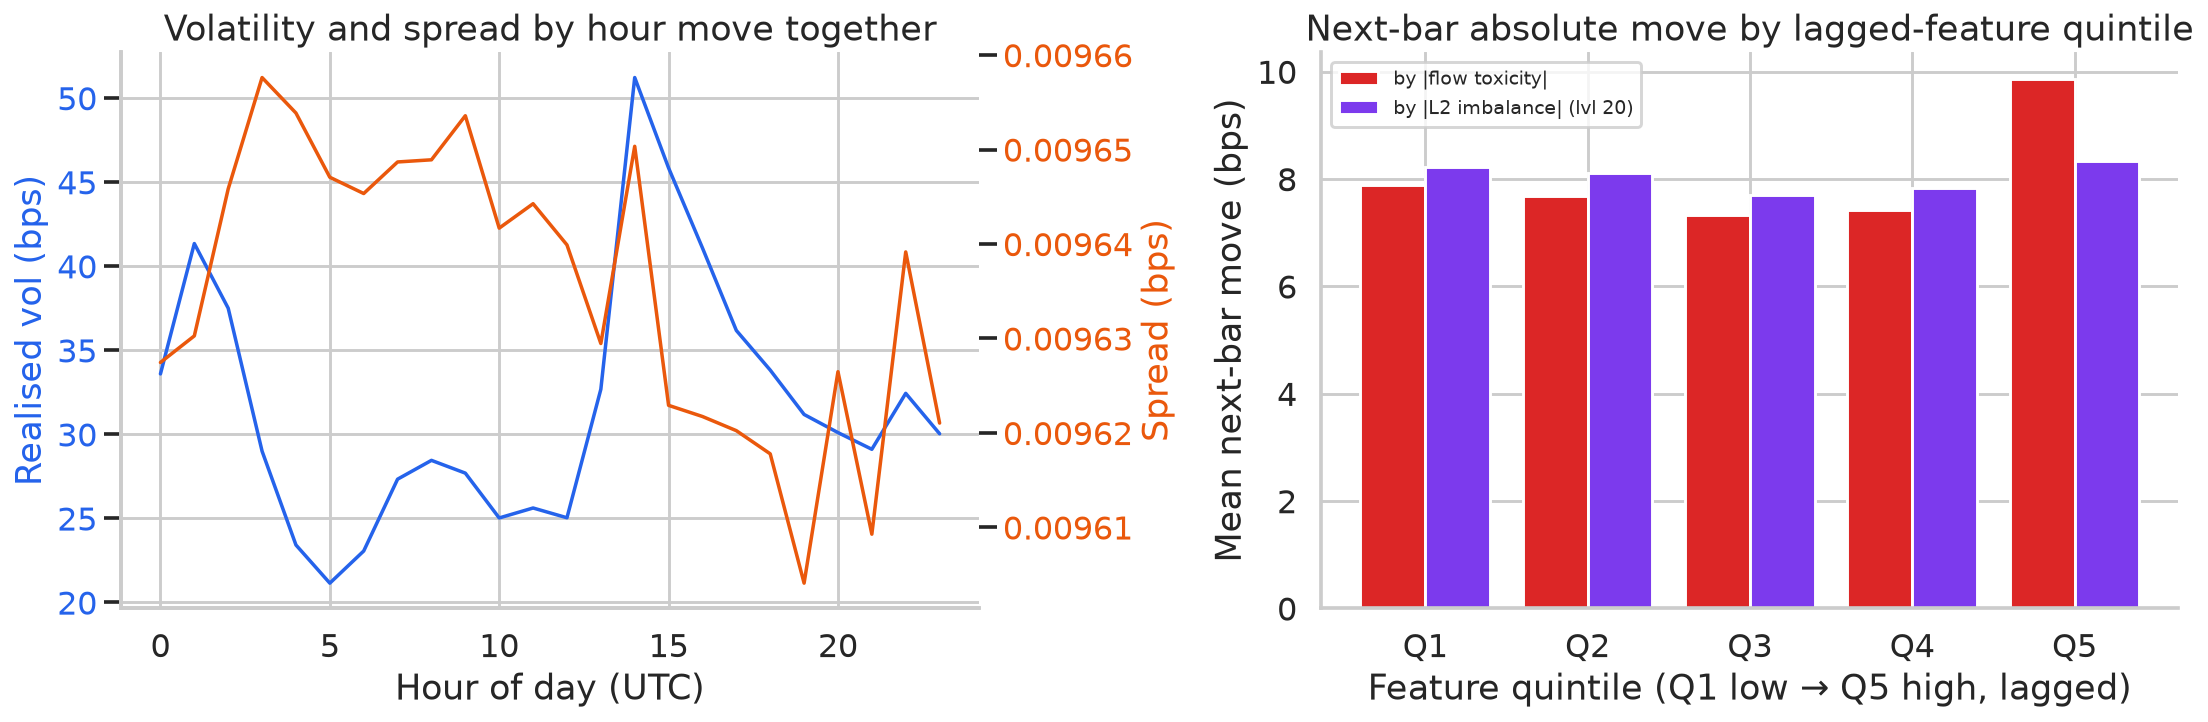

In [8]:
fig, (ax_v, ax_t) = plt.subplots(1, 2, figsize=(16, 5.5))

hourly = df.groupby("hour").agg(spread_bps=("spread_bps", "median"), vol_bps=("realized_vol_1h_bps", "median"))
ax_v.plot(hourly.index, hourly["vol_bps"], color="#2563eb", linewidth=1.8, label="Median realised vol (bps)")
ax_v.set_xlabel("Hour of day (UTC)")
ax_v.set_ylabel("Realised vol (bps)", color="#2563eb")
ax_v.tick_params(axis="y", labelcolor="#2563eb")
ax_vs = ax_v.twinx()
ax_vs.plot(hourly.index, hourly["spread_bps"], color="#ea580c", linewidth=1.8, label="Median spread (bps)")
ax_vs.set_ylabel("Spread (bps)", color="#ea580c")
ax_vs.tick_params(axis="y", labelcolor="#ea580c")
ax_vs.grid(False)
ax_v.set_title("Volatility and spread by hour move together")

labels = [f"Q{i}" for i in range(1, 6)]
diag = df[["abs_toxicity", f"imbalance_{DEPTH_LEVEL}", "fwd_abs_move_bps"]].dropna().copy()
diag["abs_imbalance"] = diag[f"imbalance_{DEPTH_LEVEL}"].abs()
diag["tox_q"] = quintile_labels(diag["abs_toxicity"], 5)
diag["imb_q"] = quintile_labels(diag["abs_imbalance"], 5)
tox_adv = diag.groupby("tox_q", observed=True)["fwd_abs_move_bps"].mean().reindex(labels)
imb_adv = diag.groupby("imb_q", observed=True)["fwd_abs_move_bps"].mean().reindex(labels)
qx = np.arange(len(labels))
bar_w = 0.4
ax_t.bar(qx - bar_w / 2, tox_adv.to_numpy(), width=bar_w, color="#dc2626", label="by |flow toxicity|")
ax_t.bar(qx + bar_w / 2, imb_adv.to_numpy(), width=bar_w, color="#7c3aed", label=f"by |L2 imbalance| (lvl {DEPTH_LEVEL})")
ax_t.set_title("Next-bar absolute move by lagged-feature quintile")
ax_t.set_xlabel("Feature quintile (Q1 low → Q5 high, lagged)")
ax_t.set_ylabel("Mean next-bar move (bps)")
ax_t.set_xticks(qx, labels)
ax_t.legend(frameon=True, fontsize=10)
plt.tight_layout()

## 7. Ranking the hours by execution cost

We rank the hours by modelled execution cost for a fixed `ORDER_NOTIONAL` and
compare the cheapest `BEST_K_HOURS`, a uniform all-day schedule, and the priciest
`BEST_K_HOURS`. Because the cost distribution is heavy-tailed (mean ≫ median, so a
few stressed bars dominate hour means), we rank on the **median** hourly cost.

This ranking is **in-sample and descriptive**: the same month both picks the hours
and scores them, so `best ≤ uniform ≤ worst` holds by construction — read it as a
view of May-2025 seasonality, not a validated edge. As an independent check we also
report how well the model's hourly ordering agrees with **measured** slippage.

In [9]:
hour_cost = df.groupby("hour")["expected_cost_bps"].median().sort_values()
best_hours = hour_cost.head(BEST_K_HOURS).index.tolist()    # cheapest hours (in-sample)
worst_hours = hour_cost.tail(BEST_K_HOURS).index.tolist()   # priciest hours (in-sample)


def _hours(frame, hours):
    return frame if hours is None else frame[frame["hour"].isin(hours)]


uniform_cost = df["expected_cost_bps"]
schedule = pd.DataFrame(
    [
        {"schedule": f"Best {BEST_K_HOURS} hours", "hours": sorted(best_hours),
         "mean_bps": _hours(df, best_hours)["expected_cost_bps"].mean(),
         "median_bps": _hours(df, best_hours)["expected_cost_bps"].median()},
        {"schedule": "Uniform (all day)", "hours": "all 24",
         "mean_bps": uniform_cost.mean(), "median_bps": uniform_cost.median()},
        {"schedule": f"Worst {BEST_K_HOURS} hours", "hours": sorted(worst_hours),
         "mean_bps": _hours(df, worst_hours)["expected_cost_bps"].mean(),
         "median_bps": _hours(df, worst_hours)["expected_cost_bps"].median()},
    ]
)
schedule["median_diff_vs_uniform"] = schedule["median_bps"] - uniform_cost.median()

# Independent cross-check: does the model's hourly ranking agree with measured
# slippage? (Both computed on the full month — this is not a train/test split.)
slip_agreement = rank_corr(
    df.groupby("hour")["expected_cost_bps"].median(),
    df.groupby("hour")["slippage_bps_mean"].median(),
)

print(f"In-sample schedule cost for a ${ORDER_NOTIONAL:,} order (hours ranked on the full month):")
print(schedule.to_markdown(index=False))
print(f"\nModel vs measured-slippage hourly ranking (Spearman): {slip_agreement:.2f}")
print(
    "Best ≤ uniform ≤ worst holds by construction here — the same month picks and scores the hours — "
    "so read the table as a description of May-2025 seasonality, not a validated edge. The "
    "measured-slippage agreement above is the independent check: a positive value means the model's "
    "cheap hours were also cheap in realised slippage."
)

In-sample schedule cost for a $50,000 order (hours ranked on the full month):
| schedule          | hours            |   mean_bps |   median_bps |   median_diff_vs_uniform |
|:------------------|:-----------------|-----------:|-------------:|-------------------------:|
| Best 4 hours      | [9, 11, 12, 14]  |   0.169234 |    0.0396614 |              -0.00478149 |
| Uniform (all day) | all 24           |   0.214144 |    0.0444429 |               0          |
| Worst 4 hours     | [19, 20, 21, 22] |   0.166894 |    0.0537361 |               0.00929319 |

Model vs measured-slippage hourly ranking (Spearman): 0.19
Best ≤ uniform ≤ worst holds by construction here — the same month picks and scores the hours — so read the table as a description of May-2025 seasonality, not a validated edge. The measured-slippage agreement above is the independent check: a positive value means the model's cheap hours were also cheap in realised slippage.


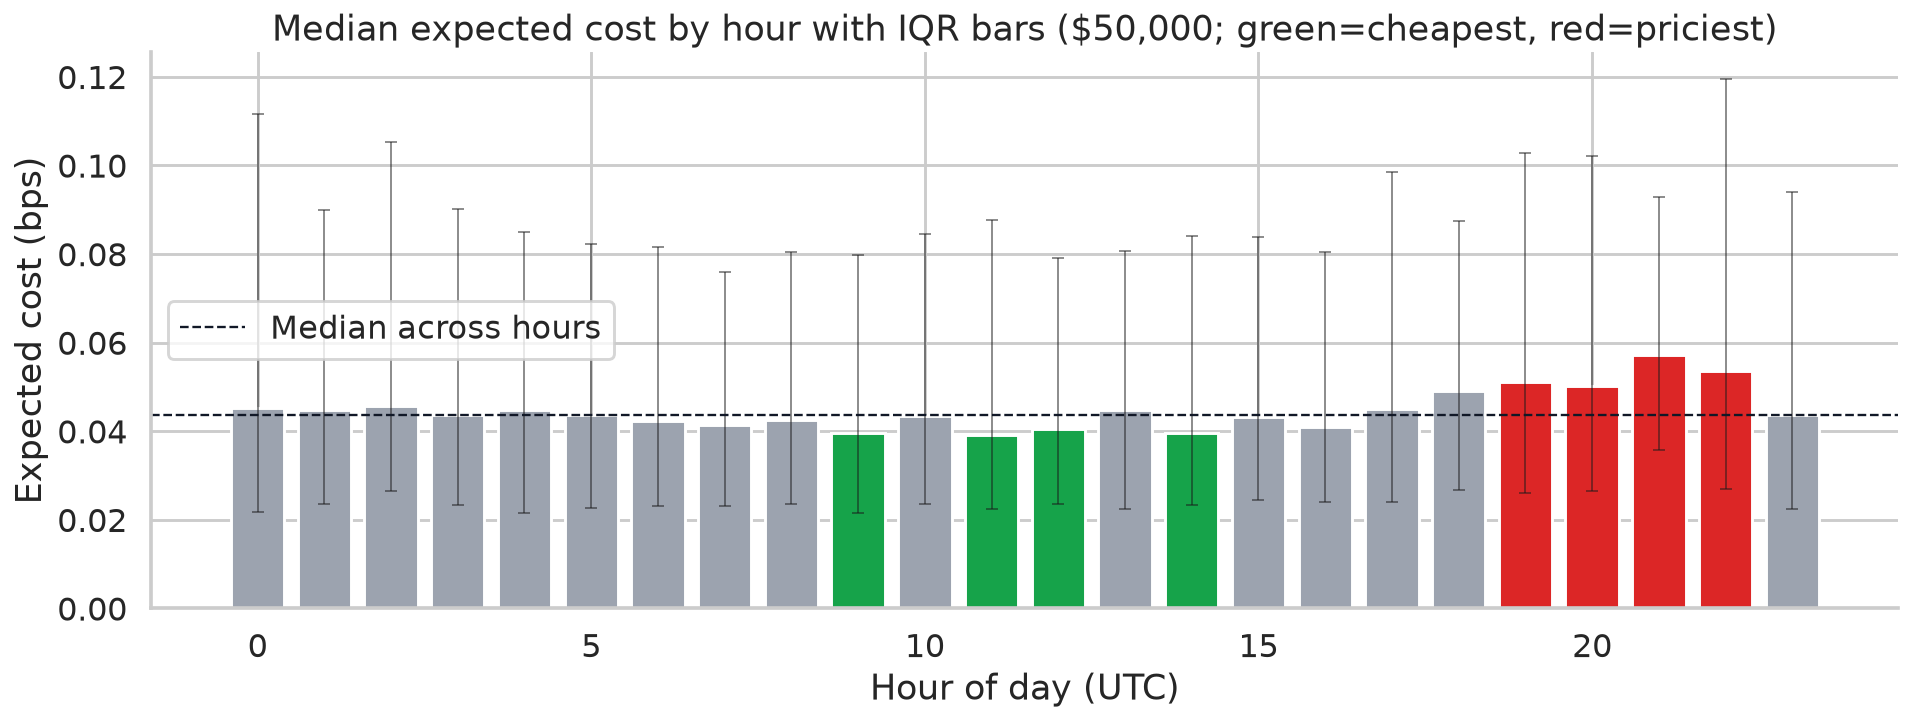

In [10]:
# Dispersion: hourly median cost (full month) with inter-quartile error bars, so the
# reader can see whether the best/worst hour means are separated or overlapping.
hourly_cost = df.groupby("hour")["expected_cost_bps"]
med = hourly_cost.median()
q25 = hourly_cost.quantile(0.25)
q75 = hourly_cost.quantile(0.75)
colors = ["#16a34a" if h in best_hours else "#dc2626" if h in worst_hours else "#9ca3af" for h in med.index]

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(med.index, med.to_numpy(), color=colors,
       yerr=[med.to_numpy() - q25.to_numpy(), q75.to_numpy() - med.to_numpy()],
       error_kw={"elinewidth": 1, "alpha": 0.5}, capsize=3)
ax.axhline(med.median(), color="#111827", linestyle="--", linewidth=1.2, label="Median across hours")
ax.set_title(f"Median expected cost by hour with IQR bars (${ORDER_NOTIONAL:,}; green=cheapest, red=priciest)")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Expected cost (bps)")
ax.legend(frameon=True)
plt.tight_layout()

# Liquidity score (holistic quality) — retained as a diagnostic for Chart 4. Note
# score_spread and score_impact are, by construction, close to expected_cost, so the
# score's extra information over cost is really depth + |toxicity|.
df["score_spread"] = 1.0 - pct_rank(df["spread_bps"])
df["score_depth"] = pct_rank(df[f"depth_{DEPTH_LEVEL}"])
df["score_impact"] = 1.0 - pct_rank(df["impact_coef_bps_per_usd"])
df["score_toxicity"] = 1.0 - pct_rank(df["abs_toxicity"])
df["liquidity_score"] = df[["score_spread", "score_depth", "score_impact", "score_toxicity"]].mean(axis=1)

## 8. Chart 4 — When to stand aside

A cheap hour is not automatically a safe one. The scatter places each hour by mean
depth (x) against mean **|toxicity|** (y); the cheapest hours are
green, the priciest red. Because the cost model is ~98% impact term, "cheap vs
expensive" here is largely an *impact* ranking — depth and toxicity carry the
information cost alone misses, so watch the **high-|toxicity|** hours even when
depth looks ample.

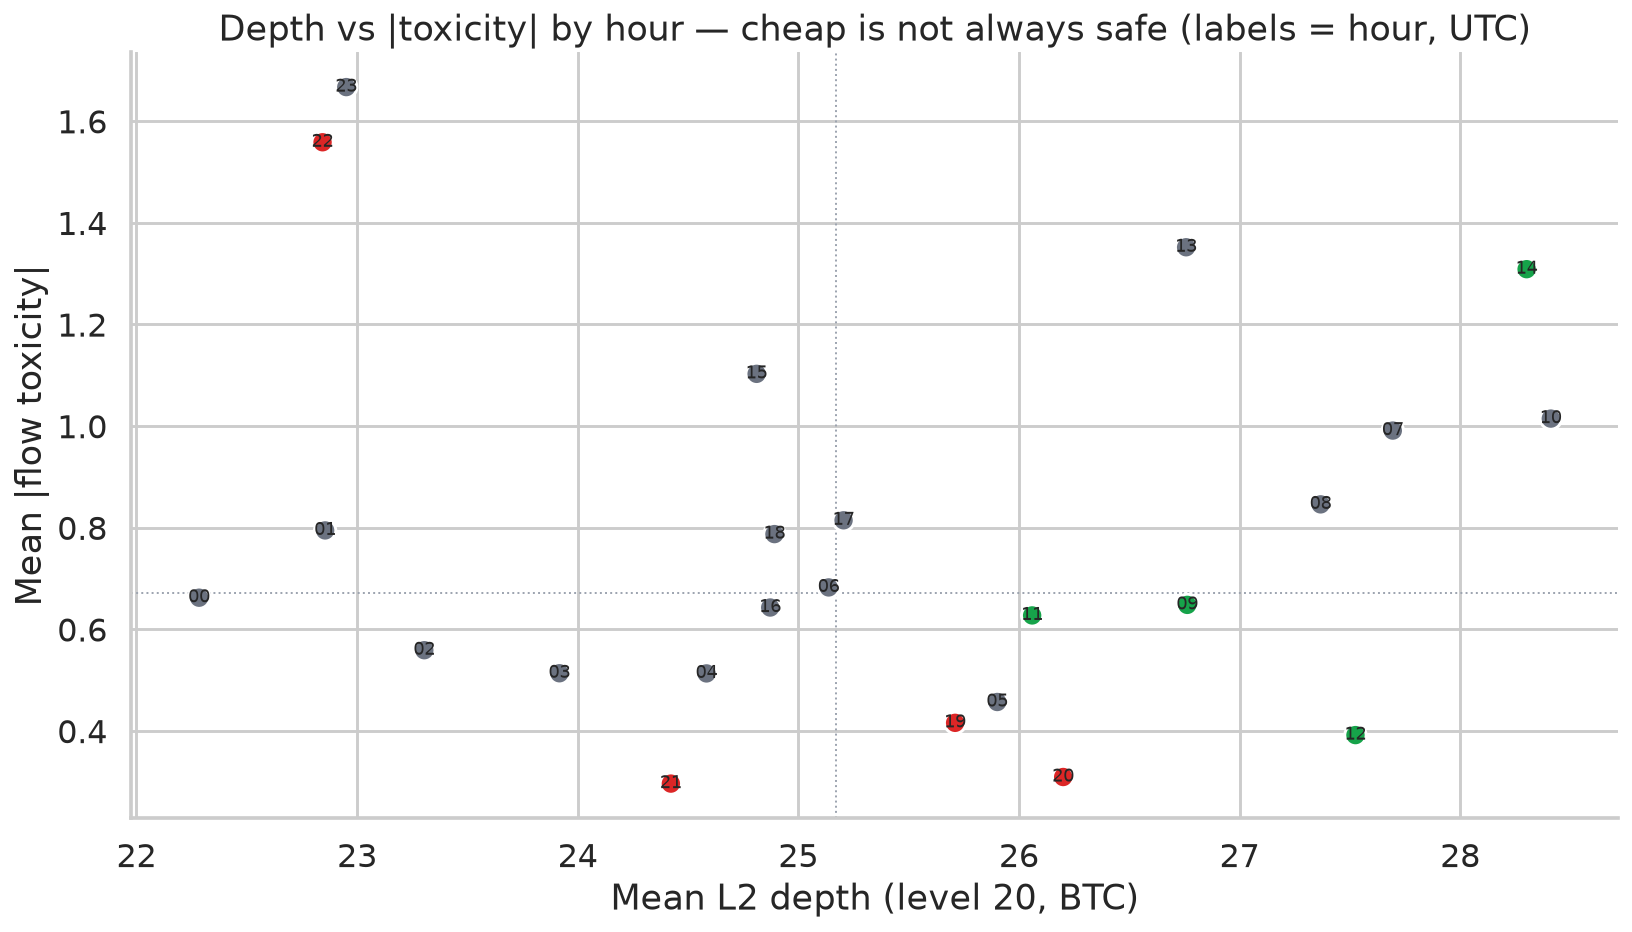

In [11]:
hour_scatter = df.groupby("hour").agg(
    depth=(f"depth_{DEPTH_LEVEL}", "mean"),
    toxicity=("abs_toxicity", "mean"),
    cost=("expected_cost_bps", "median"),
)
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#16a34a" if h in best_hours else "#dc2626" if h in worst_hours else "#6b7280" for h in hour_scatter.index]
ax.scatter(hour_scatter["depth"], hour_scatter["toxicity"], s=120, c=colors, edgecolor="white", zorder=3)
for h, row in hour_scatter.iterrows():
    ax.annotate(f"{h:02d}", (row["depth"], row["toxicity"]), fontsize=9, ha="center", va="center")
ax.axhline(hour_scatter["toxicity"].median(), color="#9ca3af", linestyle=":", linewidth=1)
ax.axvline(hour_scatter["depth"].median(), color="#9ca3af", linestyle=":", linewidth=1)
ax.set_title("Depth vs |toxicity| by hour — cheap is not always safe (labels = hour, UTC)")
ax.set_xlabel(f"Mean L2 depth (level {DEPTH_LEVEL}, BTC)")
ax.set_ylabel("Mean |flow toxicity|")
plt.tight_layout()

## Takeaways

- **This ranking is in-sample.** Picking and scoring the hours on the same month
  makes `best ≤ uniform ≤ worst` true by construction, so the gap describes
  May-2025 seasonality rather than proving a durable edge. The measured-slippage
  agreement (`slip_agreement`) is the independent cross-check; one month rarely
  settles it — and saying so *is* the lesson about one-month seasonality.
- **Rank on the median, not the mean.** The cost distribution is heavy-tailed, so a
  few stressed bars can flip an hour between "best" and "worst" under a mean.
- **Cost scales with order size, and BTC is deep.** The coverage table shows
  `ORDER_NOTIONAL` as a small share of level-`DEPTH_LEVEL` depth, so the impact term
  — and any schedule gap — grows with your notional; re-run with your own size.
- **Cheap is not always safe.** The cost model is impact-dominated; Chart 4's
  depth and |toxicity| carry the adverse-selection information cost alone misses.
- **Historical, not Live; fees cancel.** These hours are ranked in-window;
  operating forward needs Live data and full L2 history needs Prime. A constant
  taker fee shifts all schedules equally, so it is omitted here.

## Further reading
- [Execute smarter](https://aperiodic.io/use-cases/execute-smarter)
- [L1 metrics](https://aperiodic.io/metrics/l1) · [L2 metrics](https://aperiodic.io/metrics/l2) · [Trade metrics](https://aperiodic.io/metrics/trades)
- Cost-model prerequisite: `notebooks/backtest-slippage.py`
- Related notebook: `notebooks/intro-l1-price.py`